
<div style="background-color:rgba(0, 120, 255, 0.6);border-radius:5px;display:fill">
    <h1><center>Tabular Playground Series - April 2022</center></h1>
</div>
We are given 12 sensor data and based on the sensor data we need to do binary classification. Time series classification is very well known concept in  industry applications. For example, in a typical stress test patient is asked to run on the treadmill with various sensors attached to him as shown below. This sensor information is used in Medical diagonasis. Various efforts are made by several other kagglers to solve this issue. 

<img src="https://interpretersontherun.files.wordpress.com/2018/04/homer-simpson-running-gif-downsized.gif?w=500&h=351&crop=1&zoom=2" width="750" align="center">>



<div class="alert alert-block alert-info"> 📌 
    <b>In this public notebook, I will showcase how some ofthe tricks which might be helpful for this and future competitions </div>





## <span style="color:crimson;"> DONT FORGET TO UPVOTE IF YOU FIND IT USEFUL.......!!!!!! </span>

## <font color="#blue">The structure of notebook.</font>
<a id="1"></a><h2></h2>
### <a href='#1'>1. Introduction </a><br>
### <a href='#2'>2. Importing Libraries and preprocessing</a><br>
### <a href='#3'>3. Trick-1: Converting tabular data to image data</a><br>
### <a href='#4'>4. Trick-2: Train and tune your model with one line code, Grand Master way</a><br>
### <a href='#5'>5. Trick-3: QC your model with one line code</a><br>
### <a href='#6'>6. Trick-4: Speedup your model with Intex</a><br>
### <a href='#7'>7. Trick-5: Faster dataframe processing using moodle</a><br>
### <a href='#8'>8. Trick-6: Fast aggregation of large data using Python datatable</a><br>
### <a href='#9'>9. Trick-7: Get quick intuition with Lazypredict</a><br>
### <a href='#10'>10. Trick-8: Automatic EDA with Dataprep </a><br>
### <a href='#11'>11. References</a><br>

<a id="2"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>Importing Libraries and preprocessing</center></h1>
</div>

In [1]:
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()
from fastbook import *
from fastai.vision.all import *

In [2]:
## Basic packages
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import re
sns.set_style('whitegrid')
from sklearn.preprocessing import MinMaxScaler
plt.rc('image', cmap='Greys')
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.precision", 8)

In [3]:
# read sensor information with more than 600 features
# ref: https://www.kaggle.com/code/lucasmorin/feature-engineering-aggregation-functions
train = pd.read_parquet('../input/fedata-tpsapril/train.parquet')
train.head(2)

,sensor_00_mean,sensor_00_sum,sensor_00_length,sensor_00_standard_deviation,sensor_00_variation_coefficient,sensor_00_variance,sensor_00_skewness,sensor_00_kurtosis,sensor_00_abs_energy,sensor_00_root_mean_square,sensor_00_sum_values,sensor_00_realized_volatility,sensor_00_realized_abs_skew,sensor_00_realized_skew,sensor_00_realized_vol_skew,sensor_00_realized_quarticity,sensor_00_minimum,sensor_00_median,sensor_00_maximum,sensor_00_quantile_01,sensor_00_quantile_025,sensor_00_quantile_075,sensor_00_quantile_09,sensor_00_absolute_maximum,sensor_00_max_over_min,sensor_00_max_over_min_sq,sensor_00_last_location_of_maximum,sensor_00_first_location_of_maximum,sensor_00_last_location_of_minimum,sensor_00_first_location_of_minimum,sensor_00_number_peaks_2,sensor_00_mean_n_absolute_max_2,sensor_00_number_peaks_5,sensor_00_mean_n_absolute_max_5,sensor_00_number_peaks_10,sensor_00_mean_n_absolute_max_10,sensor_00_count_unique,sensor_00_count,sensor_00_count_above_0,sensor_00_count_below_0,sensor_00_value_count_0,sensor_00_count_near_0_0,sensor_00_mean_abs_change,sensor_00_mean_change,sensor_00_mean_second_derivative_central,sensor_00_absolute_sum_of_changes,sensor_00_number_crossing_0,sensor_00_variance_std_ratio,sensor_00_ratio_beyond_01_sigma,sensor_00_ratio_beyond_02_sigma,sensor_00_ratio_beyond_03_sigma,sensor_00_large_standard_deviation,sensor_00_range_ratio,sensor_01_mean,sensor_01_sum,sensor_01_length,sensor_01_standard_deviation,sensor_01_variation_coefficient,sensor_01_variance,sensor_01_skewness,sensor_01_kurtosis,sensor_01_abs_energy,sensor_01_root_mean_square,sensor_01_sum_values,sensor_01_realized_volatility,sensor_01_realized_abs_skew,sensor_01_realized_skew,sensor_01_realized_vol_skew,sensor_01_realized_quarticity,sensor_01_minimum,sensor_01_median,sensor_01_maximum,sensor_01_quantile_01,sensor_01_quantile_025,sensor_01_quantile_075,sensor_01_quantile_09,sensor_01_absolute_maximum,sensor_01_max_over_min,sensor_01_max_over_min_sq,sensor_01_last_location_of_maximum,sensor_01_first_location_of_maximum,sensor_01_last_location_of_minimum,sensor_01_first_location_of_minimum,sensor_01_number_peaks_2,sensor_01_mean_n_absolute_max_2,sensor_01_number_peaks_5,sensor_01_mean_n_absolute_max_5,sensor_01_number_peaks_10,sensor_01_mean_n_absolute_max_10,sensor_01_count_unique,sensor_01_count,sensor_01_count_above_0,sensor_01_count_below_0,sensor_01_value_count_0,sensor_01_count_near_0_0,sensor_01_mean_abs_change,sensor_01_mean_change,sensor_01_mean_second_derivative_central,sensor_01_absolute_sum_of_changes,sensor_01_number_crossing_0,sensor_01_variance_std_ratio,sensor_01_ratio_beyond_01_sigma,sensor_01_ratio_beyond_02_sigma,sensor_01_ratio_beyond_03_sigma,sensor_01_large_standard_deviation,sensor_01_range_ratio,sensor_02_mean,sensor_02_sum,sensor_02_length,sensor_02_standard_deviation,sensor_02_variation_coefficient,sensor_02_variance,sensor_02_skewness,sensor_02_kurtosis,sensor_02_abs_energy,sensor_02_root_mean_square,sensor_02_sum_values,sensor_02_realized_volatility,sensor_02_realized_abs_skew,sensor_02_realized_skew,sensor_02_realized_vol_skew,sensor_02_realized_quarticity,sensor_02_minimum,sensor_02_median,sensor_02_maximum,sensor_02_quantile_01,sensor_02_quantile_025,sensor_02_quantile_075,sensor_02_quantile_09,sensor_02_absolute_maximum,sensor_02_max_over_min,sensor_02_max_over_min_sq,sensor_02_last_location_of_maximum,sensor_02_first_location_of_maximum,sensor_02_last_location_of_minimum,sensor_02_first_location_of_minimum,sensor_02_number_peaks_2,sensor_02_mean_n_absolute_max_2,sensor_02_number_peaks_5,sensor_02_mean_n_absolute_max_5,sensor_02_number_peaks_10,sensor_02_mean_n_absolute_max_10,sensor_02_count_unique,sensor_02_count,sensor_02_count_above_0,sensor_02_count_below_0,sensor_02_value_count_0,sensor_02_count_near_0_0,sensor_02_mean_abs_change,sensor_02_mean_change,sensor_02_mean_second_derivative_central,sensor_02_absolute_sum_of_changes,sensor_02_number_crossing_0,sensor_02_variance_std_ratio,sensor_02_ratio_beyond_0

In [4]:
# lets investigate the train data
train.reset_index(inplace=True)
train.describe()

,sequence,sensor_00_mean,sensor_00_sum,sensor_00_length,sensor_00_standard_deviation,sensor_00_variation_coefficient,sensor_00_variance,sensor_00_skewness,sensor_00_kurtosis,sensor_00_abs_energy,sensor_00_root_mean_square,sensor_00_sum_values,sensor_00_realized_volatility,sensor_00_realized_abs_skew,sensor_00_realized_skew,sensor_00_realized_vol_skew,sensor_00_realized_quarticity,sensor_00_minimum,sensor_00_median,sensor_00_maximum,sensor_00_quantile_01,sensor_00_quantile_025,sensor_00_quantile_075,sensor_00_quantile_09,sensor_00_absolute_maximum,sensor_00_max_over_min,sensor_00_max_over_min_sq,sensor_00_last_location_of_maximum,sensor_00_first_location_of_maximum,sensor_00_last_location_of_minimum,sensor_00_first_location_of_minimum,sensor_00_number_peaks_2,sensor_00_mean_n_absolute_max_2,sensor_00_number_peaks_5,sensor_00_mean_n_absolute_max_5,sensor_00_number_peaks_10,sensor_00_mean_n_absolute_max_10,sensor_00_count_unique,sensor_00_count,sensor_00_count_above_0,sensor_00_count_below_0,sensor_00_value_count_0,sensor_00_count_near_0_0,sensor_00_mean_abs_change,sensor_00_mean_change,sensor_00_mean_second_derivative_central,sensor_00_absolute_sum_of_changes,sensor_00_number_crossing_0,sensor_00_variance_std_ratio,sensor_00_ratio_beyond_01_sigma,sensor_00_ratio_beyond_02_sigma,sensor_00_ratio_beyond_03_sigma,sensor_00_large_standard_deviation,sensor_00_range_ratio,sensor_01_mean,sensor_01_sum,sensor_01_length,sensor_01_standard_deviation,sensor_01_variation_coefficient,sensor_01_variance,sensor_01_skewness,sensor_01_kurtosis,sensor_01_abs_energy,sensor_01_root_mean_square,sensor_01_sum_values,sensor_01_realized_volatility,sensor_01_realized_abs_skew,sensor_01_realized_skew,sensor_01_realized_vol_skew,sensor_01_realized_quarticity,sensor_01_minimum,sensor_01_median,sensor_01_maximum,sensor_01_quantile_01,sensor_01_quantile_025,sensor_01_quantile_075,sensor_01_quantile_09,sensor_01_absolute_maximum,sensor_01_max_over_min,sensor_01_max_over_min_sq,sensor_01_last_location_of_maximum,sensor_01_first_location_of_maximum,sensor_01_last_location_of_minimum,sensor_01_first_location_of_minimum,sensor_01_number_peaks_2,sensor_01_mean_n_absolute_max_2,sensor_01_number_peaks_5,sensor_01_mean_n_absolute_max_5,sensor_01_number_peaks_10,sensor_01_mean_n_absolute_max_10,sensor_01_count_unique,sensor_01_count,sensor_01_count_above_0,sensor_01_count_below_0,sensor_01_value_count_0,sensor_01_count_near_0_0,sensor_01_mean_abs_change,sensor_01_mean_change,sensor_01_mean_second_derivative_central,sensor_01_absolute_sum_of_changes,sensor_01_number_crossing_0,sensor_01_variance_std_ratio,sensor_01_ratio_beyond_01_sigma,sensor_01_ratio_beyond_02_sigma,sensor_01_ratio_beyond_03_sigma,sensor_01_large_standard_deviation,sensor_01_range_ratio,sensor_02_mean,sensor_02_sum,sensor_02_length,sensor_02_standard_deviation,sensor_02_variation_coefficient,sensor_02_variance,sensor_02_skewness,sensor_02_kurtosis,sensor_02_abs_energy,sensor_02_root_mean_square,sensor_02_sum_values,sensor_02_realized_volatility,sensor_02_realized_abs_skew,sensor_02_realized_skew,sensor_02_realized_vol_skew,sensor_02_realized_quarticity,sensor_02_minimum,sensor_02_median,sensor_02_maximum,sensor_02_quantile_01,sensor_02_quantile_025,sensor_02_quantile_075,sensor_02_quantile_09,sensor_02_absolute_maximum,sensor_02_max_over_min,sensor_02_max_over_min_sq,sensor_02_last_location_of_maximum,sensor_02_first_location_of_maximum,sensor_02_last_location_of_minimum,sensor_02_first_location_of_minimum,sensor_02_number_peaks_2,sensor_02_mean_n_absolute_max_2,sensor_02_number_peaks_5,sensor_02_mean_n_absolute_max_5,sensor_02_number_peaks_10,sensor_02_mean_n_absolute_max_10,sensor_02_count_unique,sensor_02_count,sensor_02_count_above_0,sensor_02_count_below_0,sensor_02_value_count_0,sensor_02_count_near_0_0,sensor_02_mean_abs_change,sensor_02_mean_change,sensor_02_mean_second_derivative_central,sensor_02_absolute_sum_of_changes,sensor_02_number_crossing_0,sensor_02_variance_std_ratio,sensor_02_ratio

In [5]:
# is there any missing data
train.isnull().sum()

sequence                               0
sensor_00_mean                         0
sensor_00_sum                          0
sensor_00_length                       0
sensor_00_standard_deviation           0
                                      ..
sensor_12_ratio_beyond_02_sigma        0
sensor_12_ratio_beyond_03_sigma        0
sensor_12_large_standard_deviation    19
sensor_12_range_ratio                 19
count_sequence                         0
Length: 691, dtype: int64

In [6]:
# merging the train data with the target information
labels = pd.read_csv("../input/tabular-playground-series-apr-2022/train_labels.csv")
train_df_lable = pd.merge(train, labels, on="sequence")
train_df_lable.tail(2)

,sequence,sensor_00_mean,sensor_00_sum,sensor_00_length,sensor_00_standard_deviation,sensor_00_variation_coefficient,sensor_00_variance,sensor_00_skewness,sensor_00_kurtosis,sensor_00_abs_energy,sensor_00_root_mean_square,sensor_00_sum_values,sensor_00_realized_volatility,sensor_00_realized_abs_skew,sensor_00_realized_skew,sensor_00_realized_vol_skew,sensor_00_realized_quarticity,sensor_00_minimum,sensor_00_median,sensor_00_maximum,sensor_00_quantile_01,sensor_00_quantile_025,sensor_00_quantile_075,sensor_00_quantile_09,sensor_00_absolute_maximum,sensor_00_max_over_min,sensor_00_max_over_min_sq,sensor_00_last_location_of_maximum,sensor_00_first_location_of_maximum,sensor_00_last_location_of_minimum,sensor_00_first_location_of_minimum,sensor_00_number_peaks_2,sensor_00_mean_n_absolute_max_2,sensor_00_number_peaks_5,sensor_00_mean_n_absolute_max_5,sensor_00_number_peaks_10,sensor_00_mean_n_absolute_max_10,sensor_00_count_unique,sensor_00_count,sensor_00_count_above_0,sensor_00_count_below_0,sensor_00_value_count_0,sensor_00_count_near_0_0,sensor_00_mean_abs_change,sensor_00_mean_change,sensor_00_mean_second_derivative_central,sensor_00_absolute_sum_of_changes,sensor_00_number_crossing_0,sensor_00_variance_std_ratio,sensor_00_ratio_beyond_01_sigma,sensor_00_ratio_beyond_02_sigma,sensor_00_ratio_beyond_03_sigma,sensor_00_large_standard_deviation,sensor_00_range_ratio,sensor_01_mean,sensor_01_sum,sensor_01_length,sensor_01_standard_deviation,sensor_01_variation_coefficient,sensor_01_variance,sensor_01_skewness,sensor_01_kurtosis,sensor_01_abs_energy,sensor_01_root_mean_square,sensor_01_sum_values,sensor_01_realized_volatility,sensor_01_realized_abs_skew,sensor_01_realized_skew,sensor_01_realized_vol_skew,sensor_01_realized_quarticity,sensor_01_minimum,sensor_01_median,sensor_01_maximum,sensor_01_quantile_01,sensor_01_quantile_025,sensor_01_quantile_075,sensor_01_quantile_09,sensor_01_absolute_maximum,sensor_01_max_over_min,sensor_01_max_over_min_sq,sensor_01_last_location_of_maximum,sensor_01_first_location_of_maximum,sensor_01_last_location_of_minimum,sensor_01_first_location_of_minimum,sensor_01_number_peaks_2,sensor_01_mean_n_absolute_max_2,sensor_01_number_peaks_5,sensor_01_mean_n_absolute_max_5,sensor_01_number_peaks_10,sensor_01_mean_n_absolute_max_10,sensor_01_count_unique,sensor_01_count,sensor_01_count_above_0,sensor_01_count_below_0,sensor_01_value_count_0,sensor_01_count_near_0_0,sensor_01_mean_abs_change,sensor_01_mean_change,sensor_01_mean_second_derivative_central,sensor_01_absolute_sum_of_changes,sensor_01_number_crossing_0,sensor_01_variance_std_ratio,sensor_01_ratio_beyond_01_sigma,sensor_01_ratio_beyond_02_sigma,sensor_01_ratio_beyond_03_sigma,sensor_01_large_standard_deviation,sensor_01_range_ratio,sensor_02_mean,sensor_02_sum,sensor_02_length,sensor_02_standard_deviation,sensor_02_variation_coefficient,sensor_02_variance,sensor_02_skewness,sensor_02_kurtosis,sensor_02_abs_energy,sensor_02_root_mean_square,sensor_02_sum_values,sensor_02_realized_volatility,sensor_02_realized_abs_skew,sensor_02_realized_skew,sensor_02_realized_vol_skew,sensor_02_realized_quarticity,sensor_02_minimum,sensor_02_median,sensor_02_maximum,sensor_02_quantile_01,sensor_02_quantile_025,sensor_02_quantile_075,sensor_02_quantile_09,sensor_02_absolute_maximum,sensor_02_max_over_min,sensor_02_max_over_min_sq,sensor_02_last_location_of_maximum,sensor_02_first_location_of_maximum,sensor_02_last_location_of_minimum,sensor_02_first_location_of_minimum,sensor_02_number_peaks_2,sensor_02_mean_n_absolute_max_2,sensor_02_number_peaks_5,sensor_02_mean_n_absolute_max_5,sensor_02_number_peaks_10,sensor_02_mean_n_absolute_max_10,sensor_02_count_unique,sensor_02_count,sensor_02_count_above_0,sensor_02_count_below_0,sensor_02_value_count_0,sensor_02_count_near_0_0,sensor_02_mean_abs_change,sensor_02_mean_change,sensor_02_mean_second_derivative_central,sensor_02_absolute_sum_of_changes,sensor_02_number_crossing_0,sensor_02_variance_std_ratio,sensor_02_ratio

In [7]:
# other kagglers suggested, groupkfold based on the subject is good idea. Lets include that
#including subject column to the dataframe
train_df = pd.read_csv('../input/tabular-playground-series-apr-2022/train.csv')
train_df_subject=train_df[['sequence','subject']].copy()
train_df_subject.drop_duplicates(inplace=True)
train_df_lable=pd.merge(train_df_lable, train_df_subject, on="sequence")
train_df_lable.tail(2)

,sequence,sensor_00_mean,sensor_00_sum,sensor_00_length,sensor_00_standard_deviation,sensor_00_variation_coefficient,sensor_00_variance,sensor_00_skewness,sensor_00_kurtosis,sensor_00_abs_energy,sensor_00_root_mean_square,sensor_00_sum_values,sensor_00_realized_volatility,sensor_00_realized_abs_skew,sensor_00_realized_skew,sensor_00_realized_vol_skew,sensor_00_realized_quarticity,sensor_00_minimum,sensor_00_median,sensor_00_maximum,sensor_00_quantile_01,sensor_00_quantile_025,sensor_00_quantile_075,sensor_00_quantile_09,sensor_00_absolute_maximum,sensor_00_max_over_min,sensor_00_max_over_min_sq,sensor_00_last_location_of_maximum,sensor_00_first_location_of_maximum,sensor_00_last_location_of_minimum,sensor_00_first_location_of_minimum,sensor_00_number_peaks_2,sensor_00_mean_n_absolute_max_2,sensor_00_number_peaks_5,sensor_00_mean_n_absolute_max_5,sensor_00_number_peaks_10,sensor_00_mean_n_absolute_max_10,sensor_00_count_unique,sensor_00_count,sensor_00_count_above_0,sensor_00_count_below_0,sensor_00_value_count_0,sensor_00_count_near_0_0,sensor_00_mean_abs_change,sensor_00_mean_change,sensor_00_mean_second_derivative_central,sensor_00_absolute_sum_of_changes,sensor_00_number_crossing_0,sensor_00_variance_std_ratio,sensor_00_ratio_beyond_01_sigma,sensor_00_ratio_beyond_02_sigma,sensor_00_ratio_beyond_03_sigma,sensor_00_large_standard_deviation,sensor_00_range_ratio,sensor_01_mean,sensor_01_sum,sensor_01_length,sensor_01_standard_deviation,sensor_01_variation_coefficient,sensor_01_variance,sensor_01_skewness,sensor_01_kurtosis,sensor_01_abs_energy,sensor_01_root_mean_square,sensor_01_sum_values,sensor_01_realized_volatility,sensor_01_realized_abs_skew,sensor_01_realized_skew,sensor_01_realized_vol_skew,sensor_01_realized_quarticity,sensor_01_minimum,sensor_01_median,sensor_01_maximum,sensor_01_quantile_01,sensor_01_quantile_025,sensor_01_quantile_075,sensor_01_quantile_09,sensor_01_absolute_maximum,sensor_01_max_over_min,sensor_01_max_over_min_sq,sensor_01_last_location_of_maximum,sensor_01_first_location_of_maximum,sensor_01_last_location_of_minimum,sensor_01_first_location_of_minimum,sensor_01_number_peaks_2,sensor_01_mean_n_absolute_max_2,sensor_01_number_peaks_5,sensor_01_mean_n_absolute_max_5,sensor_01_number_peaks_10,sensor_01_mean_n_absolute_max_10,sensor_01_count_unique,sensor_01_count,sensor_01_count_above_0,sensor_01_count_below_0,sensor_01_value_count_0,sensor_01_count_near_0_0,sensor_01_mean_abs_change,sensor_01_mean_change,sensor_01_mean_second_derivative_central,sensor_01_absolute_sum_of_changes,sensor_01_number_crossing_0,sensor_01_variance_std_ratio,sensor_01_ratio_beyond_01_sigma,sensor_01_ratio_beyond_02_sigma,sensor_01_ratio_beyond_03_sigma,sensor_01_large_standard_deviation,sensor_01_range_ratio,sensor_02_mean,sensor_02_sum,sensor_02_length,sensor_02_standard_deviation,sensor_02_variation_coefficient,sensor_02_variance,sensor_02_skewness,sensor_02_kurtosis,sensor_02_abs_energy,sensor_02_root_mean_square,sensor_02_sum_values,sensor_02_realized_volatility,sensor_02_realized_abs_skew,sensor_02_realized_skew,sensor_02_realized_vol_skew,sensor_02_realized_quarticity,sensor_02_minimum,sensor_02_median,sensor_02_maximum,sensor_02_quantile_01,sensor_02_quantile_025,sensor_02_quantile_075,sensor_02_quantile_09,sensor_02_absolute_maximum,sensor_02_max_over_min,sensor_02_max_over_min_sq,sensor_02_last_location_of_maximum,sensor_02_first_location_of_maximum,sensor_02_last_location_of_minimum,sensor_02_first_location_of_minimum,sensor_02_number_peaks_2,sensor_02_mean_n_absolute_max_2,sensor_02_number_peaks_5,sensor_02_mean_n_absolute_max_5,sensor_02_number_peaks_10,sensor_02_mean_n_absolute_max_10,sensor_02_count_unique,sensor_02_count,sensor_02_count_above_0,sensor_02_count_below_0,sensor_02_value_count_0,sensor_02_count_near_0_0,sensor_02_mean_abs_change,sensor_02_mean_change,sensor_02_mean_second_derivative_central,sensor_02_absolute_sum_of_changes,sensor_02_number_crossing_0,sensor_02_variance_std_ratio,sensor_02_ratio

In [8]:
#loading test data
# ref: https://www.kaggle.com/code/lucasmorin/feature-engineering-aggregation-functions
test = pd.read_parquet('../input/fedata-tpsapril/test.parquet')
test.reset_index(inplace=True)
test.head(2)

,sequence,sensor_00_mean,sensor_00_sum,sensor_00_length,sensor_00_standard_deviation,sensor_00_variation_coefficient,sensor_00_variance,sensor_00_skewness,sensor_00_kurtosis,sensor_00_abs_energy,sensor_00_root_mean_square,sensor_00_sum_values,sensor_00_realized_volatility,sensor_00_realized_abs_skew,sensor_00_realized_skew,sensor_00_realized_vol_skew,sensor_00_realized_quarticity,sensor_00_minimum,sensor_00_median,sensor_00_maximum,sensor_00_quantile_01,sensor_00_quantile_025,sensor_00_quantile_075,sensor_00_quantile_09,sensor_00_absolute_maximum,sensor_00_max_over_min,sensor_00_max_over_min_sq,sensor_00_last_location_of_maximum,sensor_00_first_location_of_maximum,sensor_00_last_location_of_minimum,sensor_00_first_location_of_minimum,sensor_00_number_peaks_2,sensor_00_mean_n_absolute_max_2,sensor_00_number_peaks_5,sensor_00_mean_n_absolute_max_5,sensor_00_number_peaks_10,sensor_00_mean_n_absolute_max_10,sensor_00_count_unique,sensor_00_count,sensor_00_count_above_0,sensor_00_count_below_0,sensor_00_value_count_0,sensor_00_count_near_0_0,sensor_00_mean_abs_change,sensor_00_mean_change,sensor_00_mean_second_derivative_central,sensor_00_absolute_sum_of_changes,sensor_00_number_crossing_0,sensor_00_variance_std_ratio,sensor_00_ratio_beyond_01_sigma,sensor_00_ratio_beyond_02_sigma,sensor_00_ratio_beyond_03_sigma,sensor_00_large_standard_deviation,sensor_00_range_ratio,sensor_01_mean,sensor_01_sum,sensor_01_length,sensor_01_standard_deviation,sensor_01_variation_coefficient,sensor_01_variance,sensor_01_skewness,sensor_01_kurtosis,sensor_01_abs_energy,sensor_01_root_mean_square,sensor_01_sum_values,sensor_01_realized_volatility,sensor_01_realized_abs_skew,sensor_01_realized_skew,sensor_01_realized_vol_skew,sensor_01_realized_quarticity,sensor_01_minimum,sensor_01_median,sensor_01_maximum,sensor_01_quantile_01,sensor_01_quantile_025,sensor_01_quantile_075,sensor_01_quantile_09,sensor_01_absolute_maximum,sensor_01_max_over_min,sensor_01_max_over_min_sq,sensor_01_last_location_of_maximum,sensor_01_first_location_of_maximum,sensor_01_last_location_of_minimum,sensor_01_first_location_of_minimum,sensor_01_number_peaks_2,sensor_01_mean_n_absolute_max_2,sensor_01_number_peaks_5,sensor_01_mean_n_absolute_max_5,sensor_01_number_peaks_10,sensor_01_mean_n_absolute_max_10,sensor_01_count_unique,sensor_01_count,sensor_01_count_above_0,sensor_01_count_below_0,sensor_01_value_count_0,sensor_01_count_near_0_0,sensor_01_mean_abs_change,sensor_01_mean_change,sensor_01_mean_second_derivative_central,sensor_01_absolute_sum_of_changes,sensor_01_number_crossing_0,sensor_01_variance_std_ratio,sensor_01_ratio_beyond_01_sigma,sensor_01_ratio_beyond_02_sigma,sensor_01_ratio_beyond_03_sigma,sensor_01_large_standard_deviation,sensor_01_range_ratio,sensor_02_mean,sensor_02_sum,sensor_02_length,sensor_02_standard_deviation,sensor_02_variation_coefficient,sensor_02_variance,sensor_02_skewness,sensor_02_kurtosis,sensor_02_abs_energy,sensor_02_root_mean_square,sensor_02_sum_values,sensor_02_realized_volatility,sensor_02_realized_abs_skew,sensor_02_realized_skew,sensor_02_realized_vol_skew,sensor_02_realized_quarticity,sensor_02_minimum,sensor_02_median,sensor_02_maximum,sensor_02_quantile_01,sensor_02_quantile_025,sensor_02_quantile_075,sensor_02_quantile_09,sensor_02_absolute_maximum,sensor_02_max_over_min,sensor_02_max_over_min_sq,sensor_02_last_location_of_maximum,sensor_02_first_location_of_maximum,sensor_02_last_location_of_minimum,sensor_02_first_location_of_minimum,sensor_02_number_peaks_2,sensor_02_mean_n_absolute_max_2,sensor_02_number_peaks_5,sensor_02_mean_n_absolute_max_5,sensor_02_number_peaks_10,sensor_02_mean_n_absolute_max_10,sensor_02_count_unique,sensor_02_count,sensor_02_count_above_0,sensor_02_count_below_0,sensor_02_value_count_0,sensor_02_count_near_0_0,sensor_02_mean_abs_change,sensor_02_mean_change,sensor_02_mean_second_derivative_central,sensor_02_absolute_sum_of_changes,sensor_02_number_crossing_0,sensor_02_variance_std_ratio,sensor_02_ratio

In [9]:
#adding subject column to the test dataframe
test_df = pd.read_csv('../input/tabular-playground-series-apr-2022/test.csv')
test_df_subject=test_df[['sequence','subject']].copy()
test_df_subject.drop_duplicates(inplace=True)
test_df2=pd.merge(test, test_df_subject, on="sequence")
# test_with_lable=pd.merge(test_with_lable, test_df_subject, on="sequence")
test_df2.shape

(12218, 692)

<a id="3"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>Converting tabular data to image data</center></h1>
</div>
<br>
@ambrosm was able to minimize the number of feature to less than fifty and able to reach 94% accuracy. Some other kagglers used around 600 features to reach 97.7% accuracy. I also want to take advange of well established image classfication techniques. Hence, I was motivated to find a way to handle handle large number of features and convert them to images.
The stragegy here is to convert the each row into different image hence typical image classfication techniques can be used. There are total 692 columns in train dataset. We will drop one column so we can convert each row into an image of size 23x30 with sequence as ID of that image.


In [10]:
train_df_lable.set_index("sequence", inplace = True)
train_df_lable.shape

(25968, 692)

In [11]:
# lets drop one column to make it 690 column+ target column
train_df2=train_df_lable.drop(columns=['sensor_00_mean'])
# fill in the Nan values
train_df2=train_df2.interpolate()
train_df2.isnull().sum()

sensor_00_sum                         0
sensor_00_length                      0
sensor_00_standard_deviation          0
sensor_00_variation_coefficient       0
sensor_00_variance                    0
                                     ..
sensor_12_large_standard_deviation    0
sensor_12_range_ratio                 0
count_sequence                        0
state                                 0
subject                               0
Length: 691, dtype: int64

In [12]:
# The 690 columns are converted into image of size 23 x 30
img_rows = 23
img_cols = 30
train_df_nolable=train_df2.drop(columns=['state'])

### There are total 692 columns. Similar to training we will drop one column so we can convert each row into an image of size 23x30 with sequence as ID of that image.

In [13]:
test_with_nolable=test_df2.drop(columns=['sensor_00_mean'])
test_with_nolable.set_index("sequence", inplace = True)
test_with_nolable.head(2)

,sensor_00_sum,sensor_00_length,sensor_00_standard_deviation,sensor_00_variation_coefficient,sensor_00_variance,sensor_00_skewness,sensor_00_kurtosis,sensor_00_abs_energy,sensor_00_root_mean_square,sensor_00_sum_values,sensor_00_realized_volatility,sensor_00_realized_abs_skew,sensor_00_realized_skew,sensor_00_realized_vol_skew,sensor_00_realized_quarticity,sensor_00_minimum,sensor_00_median,sensor_00_maximum,sensor_00_quantile_01,sensor_00_quantile_025,sensor_00_quantile_075,sensor_00_quantile_09,sensor_00_absolute_maximum,sensor_00_max_over_min,sensor_00_max_over_min_sq,sensor_00_last_location_of_maximum,sensor_00_first_location_of_maximum,sensor_00_last_location_of_minimum,sensor_00_first_location_of_minimum,sensor_00_number_peaks_2,sensor_00_mean_n_absolute_max_2,sensor_00_number_peaks_5,sensor_00_mean_n_absolute_max_5,sensor_00_number_peaks_10,sensor_00_mean_n_absolute_max_10,sensor_00_count_unique,sensor_00_count,sensor_00_count_above_0,sensor_00_count_below_0,sensor_00_value_count_0,sensor_00_count_near_0_0,sensor_00_mean_abs_change,sensor_00_mean_change,sensor_00_mean_second_derivative_central,sensor_00_absolute_sum_of_changes,sensor_00_number_crossing_0,sensor_00_variance_std_ratio,sensor_00_ratio_beyond_01_sigma,sensor_00_ratio_beyond_02_sigma,sensor_00_ratio_beyond_03_sigma,sensor_00_large_standard_deviation,sensor_00_range_ratio,sensor_01_mean,sensor_01_sum,sensor_01_length,sensor_01_standard_deviation,sensor_01_variation_coefficient,sensor_01_variance,sensor_01_skewness,sensor_01_kurtosis,sensor_01_abs_energy,sensor_01_root_mean_square,sensor_01_sum_values,sensor_01_realized_volatility,sensor_01_realized_abs_skew,sensor_01_realized_skew,sensor_01_realized_vol_skew,sensor_01_realized_quarticity,sensor_01_minimum,sensor_01_median,sensor_01_maximum,sensor_01_quantile_01,sensor_01_quantile_025,sensor_01_quantile_075,sensor_01_quantile_09,sensor_01_absolute_maximum,sensor_01_max_over_min,sensor_01_max_over_min_sq,sensor_01_last_location_of_maximum,sensor_01_first_location_of_maximum,sensor_01_last_location_of_minimum,sensor_01_first_location_of_minimum,sensor_01_number_peaks_2,sensor_01_mean_n_absolute_max_2,sensor_01_number_peaks_5,sensor_01_mean_n_absolute_max_5,sensor_01_number_peaks_10,sensor_01_mean_n_absolute_max_10,sensor_01_count_unique,sensor_01_count,sensor_01_count_above_0,sensor_01_count_below_0,sensor_01_value_count_0,sensor_01_count_near_0_0,sensor_01_mean_abs_change,sensor_01_mean_change,sensor_01_mean_second_derivative_central,sensor_01_absolute_sum_of_changes,sensor_01_number_crossing_0,sensor_01_variance_std_ratio,sensor_01_ratio_beyond_01_sigma,sensor_01_ratio_beyond_02_sigma,sensor_01_ratio_beyond_03_sigma,sensor_01_large_standard_deviation,sensor_01_range_ratio,sensor_02_mean,sensor_02_sum,sensor_02_length,sensor_02_standard_deviation,sensor_02_variation_coefficient,sensor_02_variance,sensor_02_skewness,sensor_02_kurtosis,sensor_02_abs_energy,sensor_02_root_mean_square,sensor_02_sum_values,sensor_02_realized_volatility,sensor_02_realized_abs_skew,sensor_02_realized_skew,sensor_02_realized_vol_skew,sensor_02_realized_quarticity,sensor_02_minimum,sensor_02_median,sensor_02_maximum,sensor_02_quantile_01,sensor_02_quantile_025,sensor_02_quantile_075,sensor_02_quantile_09,sensor_02_absolute_maximum,sensor_02_max_over_min,sensor_02_max_over_min_sq,sensor_02_last_location_of_maximum,sensor_02_first_location_of_maximum,sensor_02_last_location_of_minimum,sensor_02_first_location_of_minimum,sensor_02_number_peaks_2,sensor_02_mean_n_absolute_max_2,sensor_02_number_peaks_5,sensor_02_mean_n_absolute_max_5,sensor_02_number_peaks_10,sensor_02_mean_n_absolute_max_10,sensor_02_count_unique,sensor_02_count,sensor_02_count_above_0,sensor_02_count_below_0,sensor_02_value_count_0,sensor_02_count_near_0_0,sensor_02_mean_abs_change,sensor_02_mean_change,sensor_02_mean_second_derivative_central,sensor_02_absolute_sum_of_changes,sensor_02_number_crossing_0,sensor_02_variance_std_ratio,sensor_02_ratio_beyond_01_sigma,sensor_

In [14]:
test_with_nolable.shape, train_df_nolable.shape

((12218, 690), (25968, 690))

### Some preprocessing before converting to image

In [15]:
#scaling the train data
cols = train_df_nolable.columns 
train_scaled=pd.DataFrame(columns=cols)

for i in range(len(cols)):
    df = train_df_nolable[cols[i]]
    df_scaled = (df-df.min())/(df.max()-df.min()+1E-8)*(256**3)
    train_scaled[cols[i]] = df_scaled

In [16]:
#scaling the test data also
cols = test_with_nolable.columns 
test_scaled=pd.DataFrame(columns=cols)

for i in range(len(cols)):
    df = test_with_nolable[cols[i]]
    df_scaled = (df-df.min())/(df.max()-df.min()+1E-8)
    test_scaled[cols[i]] = df_scaled


The RGB color model is an additive color model in which the red, green, and blue primary colors of light are added together in various ways to reproduce a broad array of colors. The name of the model comes from the initials of the three additive primary colors, red, green, and blue.

<img src="https://upload.wikimedia.org/wikipedia/commons/8/89/RGB_colors.gif" width="750" align="center">>

In [17]:
# prepare a function to visualize the images
def plot_sensor(images, labels, indexes):
    num_row = 5
    num_col = 5
    fig, axes = plt.subplots(num_row, num_col, constrained_layout=True,  sharex=True, sharey=True, figsize=(3*num_col,2*num_row))
    for i in range(len(images)):
        ax = axes[i//num_col, i%num_col]
        image = images[i].reshape(img_rows, img_cols, 1)
        ax.imshow(image, cmap='Spectral')
        ax.set_title(f'{labels[i]}\n{indexes[i]}')
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.5)
    plt.show()

In [18]:
target = train_df2.state
num_classes = target.nunique()
FEATURES = [col for col in train_df2.columns if col not in ['state']]

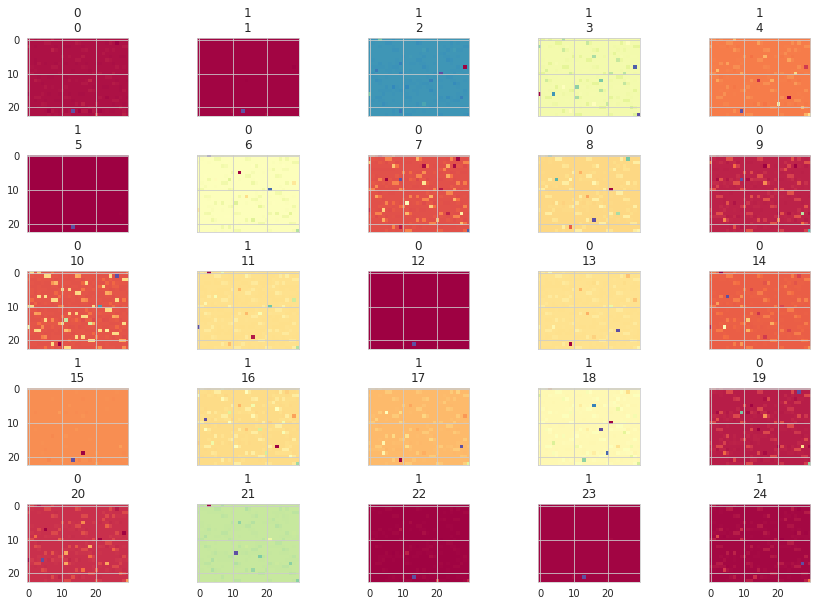

In [19]:
# Plotting first 25 sequences
images = train_df2[:25]  
labels = images.state.values
indexes = images.index.values
images = images[FEATURES].values.reshape(images.shape[0], img_rows, img_cols, 1).astype('float32')
plot_sensor(images, labels, indexes)

In [20]:
# Converting the 690 columns to 23x30 columns and visualize one of the sample 
train_df2['state'] = train_df2['state'].astype('bool') 
arr = tensor((train_scaled.iloc[1,0:690]).astype(np.float))
Long1 = torch.reshape(arr,(23,30))

### identifying the blue colors in RGB color scheme

In [21]:
Blue_clr = (Long1/65536).int()
def bluepic(img):
  df = pd.DataFrame(img)
  return df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Blues')
bluepic(Blue_clr)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
0,56,0,5,25,0,115,37,0,5,56,5,4,130,4,5,251,125,4,249,250,7,4,4,247,0,65,65,0,0,199
1,5,160,5,128,5,256,0,77,178,0,0,7,101,105,7,180,5,216,158,138,41,8,92,92,0,2,164,0,125,11
2,0,2,92,2,1,124,1,1,254,38,1,253,253,2,2,1,253,0,73,73,65,65,199,1,96,1,128,2,256,0
3,68,64,0,0,2,150,133,2,187,2,234,212,202,101,8,230,230,0,7,12,0,126,4,0,13,230,13,14,229,15
4,14,222,231,238,225,227,232,235,21,73,0,108,104,95,95,0,20,0,19,0,18,67,0,0,256,0,0,7,133,126
5,7,0,7,247,221,221,97,12,165,165,0,2,124,0,132,13,0,2,165,2,2,149,3,3,253,151,3,254,254,1
6,2,3,248,0,4,4,78,78,161,3,142,3,128,3,251,0,181,74,0,0,3,116,127,3,190,2,214,167,134,108
7,23,170,170,0,19,17,1,159,23,1,19,170,19,28,129,30,26,240,131,40,245,244,36,21,37,224,2,91,91,8
8,8,161,26,192,20,64,19,256,0,190,65,0,0,17,114,121,17,114,19,236,229,212,52,3,163,163,0,26,0,2
9,130,12,2,26,163,26,26,133,25,26,232,129,19,227,239,27,28,22,14,0,82,82,156,156,119,23,85,25,128,27


In [22]:
Green_clr = ((Long1 - Blue_clr * 65536)/256).int()
def greenpic(img):
  df = pd.DataFrame(img)
  return df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greens')
greenpic(Green_clr)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
0,14,0,244,234,35,199,26,35,245,14,245,34,182,224,54,116,147,121,219,57,25,239,139,187,15,21,21,0,0,28
1,89,0,20,0,248,0,0,101,154,0,0,44,177,240,44,180,244,70,229,216,12,202,73,73,0,50,50,4,14,42
2,4,49,73,49,167,177,156,186,97,54,112,229,75,247,3,144,215,4,195,195,21,21,28,134,0,206,0,28,0,0
3,174,0,0,0,165,79,198,165,19,20,170,156,26,70,122,226,226,0,183,199,59,240,169,183,140,226,140,18,212,73
4,136,220,63,20,72,214,245,133,103,89,0,121,34,117,117,0,33,0,94,0,192,159,0,0,0,0,0,223,200,143
5,223,0,183,119,221,221,22,175,118,118,0,229,209,8,53,83,8,231,118,231,169,11,94,63,44,67,78,95,27,51
6,174,77,172,17,86,86,26,26,175,78,56,106,0,86,169,0,18,237,0,0,28,79,245,28,190,229,219,185,130,47
7,243,16,16,0,50,248,112,214,181,124,99,16,99,137,186,176,149,177,109,77,94,117,100,205,164,169,35,30,30,173
8,173,175,145,0,156,0,112,0,0,130,125,0,0,21,212,77,21,194,50,173,247,156,70,35,78,78,0,208,0,207
9,85,41,207,206,78,206,81,163,136,153,245,114,145,161,80,156,121,37,17,2,112,112,52,52,119,75,85,193,0,157


In [23]:
#R = LONG - B * 65536 - G * 256
Red_clr = (Long1 - Blue_clr *65536 - Green_clr * 256).int()
def redpic(img):
  df = pd.DataFrame(img)
  return df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Reds')
redpic(Red_clr)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
0,89,0,189,6,121,46,11,138,121,89,121,83,96,217,234,142,232,144,106,134,202,241,45,136,132,178,178,0,0,114
1,142,0,225,0,13,0,0,53,202,0,0,43,51,154,43,181,189,159,132,243,46,35,250,250,0,107,51,211,15,148
2,208,157,250,157,221,202,252,118,241,252,24,226,38,154,133,63,214,185,65,65,178,178,114,175,0,162,0,130,0,0
3,212,0,0,0,245,214,131,245,177,133,171,52,242,150,179,162,162,0,78,14,137,226,8,135,25,162,25,29,134,221
4,14,142,243,128,1,127,127,0,255,154,1,126,182,39,39,0,247,0,89,0,211,101,0,0,0,0,0,166,35,11
5,166,0,78,119,222,222,43,196,196,196,0,194,245,101,116,93,110,0,196,0,251,89,176,89,253,253,51,70,112,77
6,221,240,167,0,199,199,8,8,40,148,228,122,0,66,56,0,187,68,0,0,119,38,91,119,191,194,110,97,43,111
7,118,213,213,0,253,160,155,197,231,83,119,213,119,156,133,232,222,213,46,158,236,97,135,85,180,237,27,95,95,143
8,143,40,121,0,58,0,83,0,0,250,6,0,0,99,221,242,99,53,253,227,82,52,191,176,167,167,0,0,0,173
9,86,98,173,46,167,46,42,70,235,62,79,251,12,2,94,160,235,54,227,182,208,208,17,17,119,203,85,19,0,248


### Lets visualize the whole RGB image

In [24]:
def bigpic(img):
  df = pd.DataFrame(img)
  return df.style.set_properties(**{'font-size':'6pt'}).background_gradient('gist_rainbow')
bigpic(Long1.int())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
0,3673689,0,390333,1698310,9081,7587630,2431499,9098,390521,3673689,390521,270931,8566368,319705,341738,16479374,8229864,293264,16374634,16398726,465354,323569,297773,16235400,3972,4265394,4265394,0,0,13048946
1,350606,10485760,333025,8388608,391181,16777216,0,5072181,11705034,0,0,470059,6664499,6942874,470059,11842741,390333,14173855,10413444,9099507,2690094,576035,6048250,6048250,0,143979,10760755,1235,8195599,731796
2,1232,143773,6048250,143773,108509,8171978,105724,113270,16671217,2504444,94232,16639458,16599846,194458,131973,102463,16635862,1209,4834113,4834113,4265394,4265394,13048946,100015,6291456,118434,8388608,138370,16777216,0
3,4501204,4194304,0,0,173557,9850838,8767107,173557,12260273,136325,15379115,13933620,13245170,6637206,555699,15131298,15131298,0,505678,837390,15241,8319202,305416,46983,887833,15131298,887833,922141,15062150,1001949
4,952334,14605454,15155187,15602816,14764033,14931583,15267199,15435008,1402879,4807066,1,7108990,6824630,6255911,6255911,0,1319415,0,1269337,0,1229011,4431717,0,0,16777216,0,0,516006,8767523,8294155
5,516006,0,505678,16217975,14540254,14540254,6362667,831428,10843844,10843844,0,189890,8180213,2149,8664436,873309,2158,190208,10843844,190208,174587,9767769,220848,212825,16592125,9913341,216627,16670534,16653168,78669
6,175837,216560,16297127,4352,284359,284359,5118472,5118472,10596136,216724,9320676,223866,8388608,218690,16492856,0,11866811,4910404,0,0,203895,7622438,8385883,203895,12500671,189890,14080878,10991969,8815147,7090031
7,1569654,11145429,11145429,0,1258237,1177760,94363,10475205,1553895,97363,1270647,11145429,1270647,1870236,8501893,2011368,1742302,15774165,8613166,2641310,16080620,16020833,2385031,1428821,2466996,14723565,140059,5971551,5971551,568719
8,568719,10596136,1741177,12582912,1350714,4194304,1273939,16777216,0,12485370,4291846,0,0,1119587,7525597,7949810,1119587,7520821,1258237,15511011,15071058,13933620,3425983,205744,10702503,10702503,0,1757184,0,184237
9,8541526,797026,184237,1756718,10702503,1756718,1724714,8758086,1673451,1743166,15267151,8483579,1282316,14917890,15683678,1809568,1866219,1451318,922083,694,5402832,5402832,10236945,10236945,7829367,1526731,5592405,1687827,8388608,1809912


### bit of post processing

In [25]:
pic = torch.stack((Red_clr.flatten(),Green_clr.flatten(),Blue_clr.flatten()))
pic.shape

torch.Size([3, 690])

<AxesSubplot:>

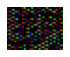

In [26]:
pic = torch.reshape(pic,(3,23,30))
pic = torch.permute(pic, (1, 2, 0))
img = Image.fromarray(pic.numpy(), 'RGB')
show_image(img)

### Finally we managed to convert a row into an image with RGB color format. Lets visualize some more samples

In [27]:
target_values = train_df2['state'].unique()
samples_df = pd.DataFrame(columns=train_df2.columns)

for i in range(len(target_values)):
    df_filter = train_df2[train_df2['state']==target_values[i]][0:10]
    samples_df = samples_df.append(df_filter)    
samples_df.shape

(20, 691)

In [28]:
def create_pics(train_scaled):
    
  pic_rgb=[]
  for i in range(len(train_scaled)):
    #cast into float tensor
    arr = tensor((train_scaled.iloc[i,0:690]).astype(np.float))

    #reshape into a picture 23x30
    Long1 = torch.reshape(arr,(23,30))

    #compute RGB channells
    Blue1 = (Long1/65536).int()
    Green1 = ((Long1 - Blue1 * 65536)/256).int()
    Red1 = (Long1 - Blue1 *65536 - Green1 * 256).int()

    #create yeansor image
    pic = torch.stack((Red1.flatten(),Green1.flatten(),Blue1.flatten()))
    pic = torch.reshape(pic,(3,23,30))
    pic = torch.permute(pic, (1, 2, 0))

    pic_rgb.append(pic)

  pic_rgb_t = torch.stack(pic_rgb)

  return pic_rgb_t

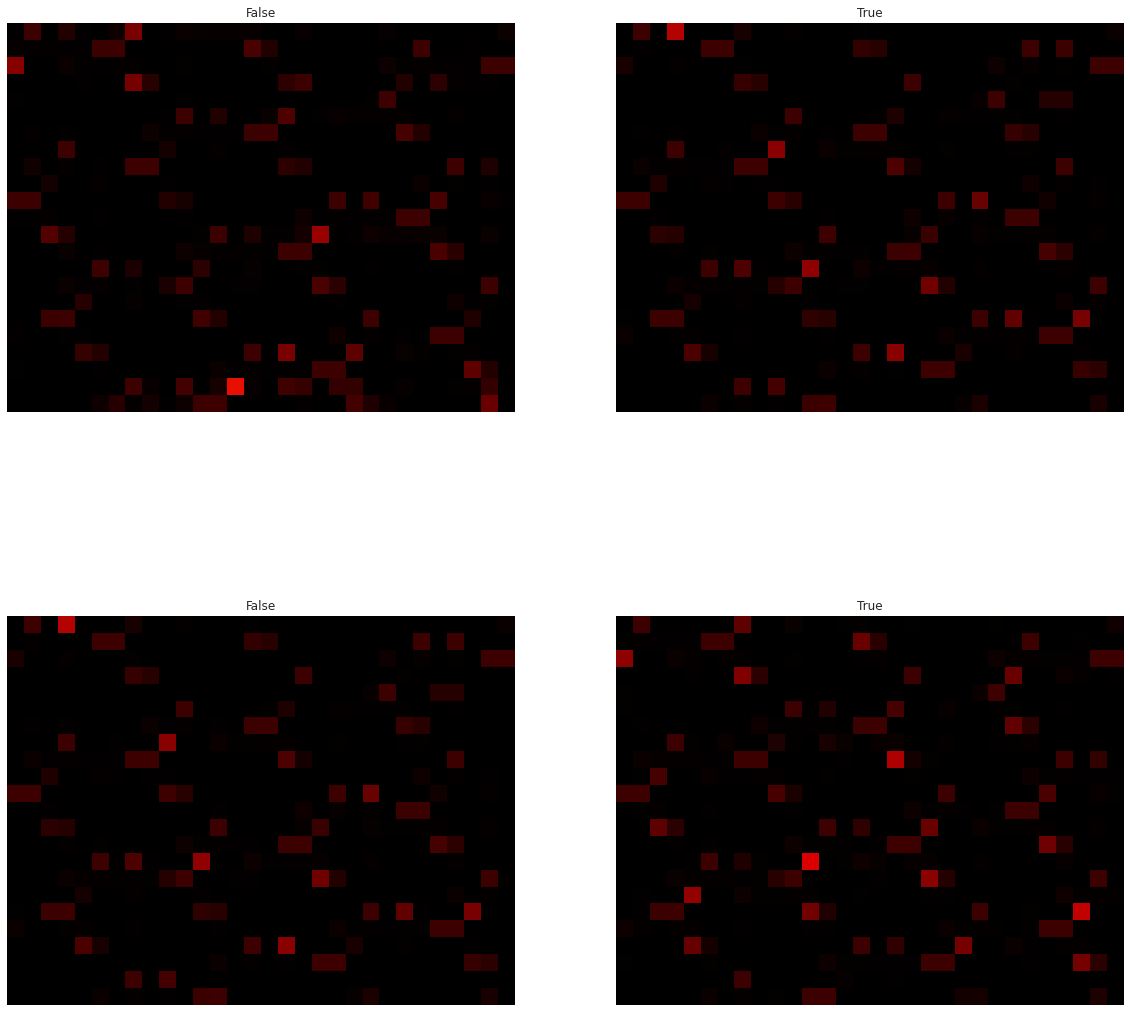

In [29]:
sample_pics = create_pics(samples_df)
fig, ax = plt.subplots(2,2, figsize=(20, 20))

for c in range(2):
    for r in range(2):
        image = sample_pics[c+r]
        ax[r, c].imshow(image)
        ax[r, c].set_title(target_values[c])
        ax[r, c].axis("off")

### A new datset can be creted which can act as an input to the any image classfication algorithums. Uncomment this section if you want to save. I have commented to save the memory

In [30]:
# new_pics_train = create_pics(train_scaled)
# #new_pics_train.shape
# train_y_labels = train_df2['state']
# new_pics_test = create_pics(test_scaled)
# torch.save(new_pics_train,'./train_Images')
# torch.save(new_pics_test,'./test_Images')

In [31]:
from IPython import get_ipython
get_ipython().magic('reset -sf') 

### <a href='#1'>Back to top </a><br>

<a id="4"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>Trick-2: Train and tune your model with one line code</center></h1>
</div>
This library is developed by <b> Grand Master Absheik Thakur </b>, which he used in several competitions. See the reference list for full details <b>

In [32]:
# preprocessing
!pip install autoxgb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 KB 240.6 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.5/173.5 MB 2.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 12.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.0/307.0 KB 20.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 15.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 11.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 KB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 KB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 13.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 KB 3.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.5
    Uninstalling numpy-1.21.5:
      Successfully uninsta

In [33]:
!autoxgb train \
--train_filename ../input/tabular-playground-series-apr-2022/train.csv \
--test_filename ../input/tabular-playground-series-apr-2022/test.csv \
--idx Id \
--task regression \
--targets state \
--time_limit 3600 \
--output petf \
--use_gpu

2022-04-26 17:22:06.633 | INFO     | autoxgb.autoxgb:__post_init__:42 - Output directory: petf
2022-04-26 17:22:06.634 | INFO     | autoxgb.autoxgb:_process_data:149 - Reading training data
2022-04-26 17:22:14.722 | INFO     | autoxgb.utils:reduce_memory_usage:50 - Mem. usage decreased to 46.06 Mb (75.8% reduction)
2022-04-26 17:22:14.722 | INFO     | autoxgb.autoxgb:_determine_problem_type:140 - Problem type: single_column_regression
2022-04-26 17:22:17.231 | INFO     | autoxgb.utils:reduce_memory_usage:50 - Mem. usage decreased to 23.07 Mb (74.2% reduction)
2022-04-26 17:22:17.235 | INFO     | autoxgb.autoxgb:_create_folds:58 - Creating folds
Traceback (most recent call last):
  File "/opt/conda/bin/autoxgb", line 8, in <module>
    sys.exit(main())
  File "/opt/conda/lib/python3.7/site-packages/autoxgb/cli/autoxgb.py", line 33, in main
    command.execute()
  File "/opt/conda/lib/python3.7/site-packages/autoxgb/cli/train.py", line 156, in execute
    axgb.train()
  File "/opt/conda/

<b> Points to note while using this trick: <br>
1) make sure all the feature engineering is completed for train and test dataset and store them in respective csv files. For illustration purpose I have ignored this. If you are planning to use this, please include all the features<br>
2) The predictions will be saved in the working directory as test_predictions.csv. <br>

### <a href='#1'>Back to top </a><br>

<a id="5"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>Trick-3: QC your model with one line code </center></h1>
</div>

Here we will utilize DeepChecks to validate your machine learning models and data, such as verifying your data’s integrity, inspecting its distributions, validating data splits, evaluating the model. Interestingly it will take only seven lines of code to do that.<br>
<br>
<br>
<img src="https://docs.deepchecks.com/stable/_images/pipeline_when_to_validate.svg" width="750" align="center">>
<br>
Here I will use one of the public notebook and QC the model as an example. All the credits for the model goes to the original author. Consider upvoting them.
https://www.kaggle.com/code/cv13j0/tps-apr-2022-xgboost-model

In [34]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re
sns.set_style('whitegrid')
from sklearn.preprocessing import MinMaxScaler
plt.rc('image', cmap='Greys')
import warnings

# Notebook Configuration...

# Amount of data we want to load into the Model...
DATA_ROWS = None
# Dataframe, the amount of rows and cols to visualize...
NROWS = 100
NCOLS = 15
# Main data location path...
BASE_PATH = '...'
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', NCOLS) 
pd.set_option('display.max_rows', NROWS)
# Load the CSVs into a pandas dataframe for future data manipulation.
trn_data = pd.read_csv('/kaggle/input/tabular-playground-series-apr-2022/train.csv')
trn_label_data = pd.read_csv('/kaggle/input/tabular-playground-series-apr-2022/train_labels.csv')
tst_data = pd.read_csv('/kaggle/input/tabular-playground-series-apr-2022/test.csv')

sub = pd.read_csv('/kaggle/input/tabular-playground-series-apr-2022/sample_submission.csv')

trn_summary = trn_data[['sequence', 'subject', 'step']].groupby(['sequence', 'subject']).count().reset_index()
trn_summary[trn_summary['subject'] == 66].shape
summary_by_subject = trn_summary[['sequence', 'subject']].groupby(['subject']).count().reset_index()
trn_unique_subjects = set(list(trn_data['subject'].unique()))
tst_unique_subjects = set(list(tst_data['subject'].unique()))
overlap_subjets = trn_unique_subjects.intersection(tst_unique_subjects)
print('Repeated Subjects in Test Dataset:', len(overlap_subjets))
from scipy.stats import kurtosis
def kurtosis_func(series):
    '''
    Describe something...
    '''
    return kurtosis(series)

def q01(series):
    return np.quantile(series, 0.01)

def q05(series):
    return np.quantile(series, 0.05)

def q95(series):
    return np.quantile(series, 0.95)

def q99(series):
    return np.quantile(series, 0.99)

def aggregated_features(df, aggregation_cols = ['sequence'], prefix = ''):
    agg_strategy = {'sensor_00': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_01': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_02': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_03': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_04': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_05': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_06': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_07': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_08': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_09': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_10': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_11': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                    'sensor_12': ['mean', 'max', 'min', 'var', 'mad', 'sum', 'median', 'skew', kurtosis_func, q01, q05, q95, q99],
                   }
    group = df.groupby(aggregation_cols).aggregate(agg_strategy)
    group.columns = ['_'.join(col).strip() for col in group.columns]
    group.columns = [str(prefix) + str(col) for col in group.columns]
    group.reset_index(inplace = True)
    
    temp = (df.groupby(aggregation_cols).size().reset_index(name = str(prefix) + 'size'))
    group = pd.merge(temp, group, how = 'left', on = aggregation_cols,)
    return group
trn_merge_data = aggregated_features(trn_data, aggregation_cols = ['sequence', 'subject'])
tst_merge_data = aggregated_features(tst_data, aggregation_cols = ['sequence', 'subject'])
trn_subjects_merge_data = aggregated_features(trn_data, aggregation_cols = ['subject'], prefix = 'subject_')
tst_subjects_merge_data = aggregated_features(tst_data, aggregation_cols = ['subject'], prefix = 'subject_')
trn_data['sensor_00_lag_01'] = trn_data['sensor_00'].shift(1)
trn_data['sensor_00_lag_10'] = trn_data['sensor_00'].shift(10)
trn_merge_data = trn_merge_data.merge(trn_label_data, how = 'left', on = 'sequence')
trn_merge_data = trn_merge_data.merge(trn_subjects_merge_data, how = 'left', on = 'subject')
tst_merge_data = tst_merge_data.merge(tst_subjects_merge_data, how = 'left', on = 'subject')
ignore = ['sequence', 'state', 'subject']
features = [feat for feat in trn_merge_data.columns if feat not in ignore]
target_feature = 'state'
from sklearn.model_selection import train_test_split
test_size_pct = 0.10
X_train, X_valid, y_train, y_valid = train_test_split(trn_merge_data[features], trn_merge_data[target_feature], test_size = test_size_pct, random_state = 42)


Repeated Subjects in Test Dataset: 0


In [35]:
from xgboost  import XGBClassifier
params = {'n_estimators': 40,  # I changed it from 4096 to 40 
          'max_depth': 7,
          'learning_rate': 0.15,
          'subsample': 0.95,
          'colsample_bytree': 0.60,
          'reg_lambda': 1.50,
          'reg_alpha': 6.10,
          'gamma': 1.40,
          'random_state': 69,
          'objective': 'binary:logistic',
         }
xgb = XGBClassifier(**params)
xgb.fit(X_train, y_train, eval_set = [(X_valid, y_valid)], eval_metric = ['auc'], early_stopping_rounds = 128, verbose = 50)
from sklearn.metrics import roc_auc_score
preds = xgb.predict_proba(X_valid)[:, 1]
score = roc_auc_score(y_valid, preds)
from sklearn.metrics import roc_auc_score
preds = xgb.predict_proba(tst_merge_data[features])[:, 1]
# end of public notebook

[0]	validation_0-auc:0.83740
[39]	validation_0-auc:0.92301


In [36]:
# Preprocessing to prepare train and test datasets
!pip install deepchecks --user
from deepchecks.tabular.suites import full_suite
from deepchecks.tabular.datasets.classification import iris
from deepchecks.tabular import Dataset

features.append("sequence")
train=trn_merge_data[features]
t_lbls=trn_merge_data[['sequence','state']]
train_with_lable=pd.merge(train, t_lbls, on="sequence")
label_col='state'
train_dataset = Dataset(train_with_lable, label=label_col, cat_features=[])
test_with_lable = tst_merge_data[features]
sub['state'] = preds
test_with_lable=pd.merge(test_with_lable, sub, on="sequence")
test_dataset = Dataset(test_with_lable, label=label_col, cat_features=[])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.0/356.0 KB 534.0 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 10.9 MB/s eta 0:00:0000:0100:01


## Now the QC the model with two lines

In [37]:
suite = full_suite()
suite.run(train_dataset=train_dataset, test_dataset=test_dataset, model=xgb)

Full Suite:   0%|          | 0/35 [00:00<?, ? Check/s]

Full Suite 
 
 The suite is composed of various checks such as: Calibration Score, Dominant Frequency Change, Regression Systematic Error, etc... 
 Each check may contain conditions (which will result in pass / fail / warning / error
 , represented by 
 ✓ /
 ✖ /
 ! /
 ⁈ 
 ) as well as other outputs such as plots or tables. 
 Suites, checks and conditions can all be modified. Read more about
 custom suites .

Status,Check,Condition,More Info
✖,Train Test Drift,PSI <= 0.2 and Earth Mover's Distance <= 0.1,Found numeric columns with Earth Mover's Distance above threshold: {'sequence': '0.5'}
✖,Single Value in Column - Train Dataset,Does not contain only a single value,Found columns with a single value: ['size']
✖,Single Value in Column - Test Dataset,Does not contain only a single value,Found columns with a single value: ['size']
✖,Train Test Label Drift,PSI <= 0.2 and Earth Mover's Distance <= 0.1 for label drift,Found label PSI above threshold: 8.39
✖,Whole Dataset Drift,Drift value is not greater than 0.25,"Found drift value of: 1, corresponding to a domain classifier AUC of: 1"
✓,Dominant Frequency Change,Change in ratio of dominant value in data is not greater than 25%,
✓,Datasets Size Comparison,Test-Train size ratio is not smaller than 0.01,
✓,Single Feature Contribution Train-Test,Train-Test features' Predictive Power Score difference is not greater than 0.2,
✓,Single Feature Contribution Train-Test,Train features' Predictive Power Score is not greater than 0.7,
✓,String Length Out Of Bounds - Test Dataset,Ratio of outliers not greater than 0% string length outliers,


Check With Conditions Output

Status,Condition,More Info
✖,PSI <= 0.2 and Earth Mover's Distance <= 0.1,Found numeric columns with Earth Mover's Distance above threshold: {'sequence': '0.5'}


...

Check Without Conditions Output

,size,sensor_00_mean,sensor_00_max,sensor_00_min,sensor_00_var,sensor_00_mad,sensor_00_sum,sensor_00_median,sensor_00_skew,sensor_00_kurtosis_func,sensor_00_q01,sensor_00_q05,sensor_00_q95,sensor_00_q99,sensor_01_mean,sensor_01_max,sensor_01_min,sensor_01_var,sensor_01_mad,sensor_01_sum,sensor_01_median,sensor_01_skew,sensor_01_kurtosis_func,sensor_01_q01,sensor_01_q05,sensor_01_q95,sensor_01_q99,sensor_02_mean,sensor_02_max,sensor_02_min,sensor_02_var,sensor_02_mad,sensor_02_sum,sensor_02_median,sensor_02_skew,sensor_02_kurtosis_func,sensor_02_q01,sensor_02_q05,sensor_02_q95,sensor_02_q99,sensor_03_mean,sensor_03_max,sensor_03_min,sensor_03_var,sensor_03_mad,sensor_03_sum,sensor_03_median,sensor_03_skew,sensor_03_kurtosis_func,sensor_03_q01,sensor_03_q05,sensor_03_q95,sensor_03_q99,sensor_04_mean,sensor_04_max,sensor_04_min,sensor_04_var,sensor_04_mad,sensor_04_sum,sensor_04_median,sensor_04_skew,sensor_04_kurtosis_func,sensor_04_q01,sensor_04_q05,sensor_04_q95,sensor_04_q99,sensor_05_mean,sensor_05_max,sensor_05_min,sensor_05_var,sensor_05_mad,sensor_05_sum,sensor_05_median,sensor_05_skew,sensor_05_kurtosis_func,sensor_05_q01,sensor_05_q05,sensor_05_q95,sensor_05_q99,sensor_06_mean,sensor_06_max,sensor_06_min,sensor_06_var,sensor_06_mad,sensor_06_sum,sensor_06_median,sensor_06_skew,sensor_06_kurtosis_func,sensor_06_q01,sensor_06_q05,sensor_06_q95,sensor_06_q99,sensor_07_mean,sensor_07_max,sensor_07_min,sensor_07_var,sensor_07_mad,sensor_07_sum,sensor_07_median,sensor_07_skew,sensor_07_kurtosis_func,sensor_07_q01,sensor_07_q05,sensor_07_q95,sensor_07_q99,sensor_08_mean,sensor_08_max,sensor_08_min,sensor_08_var,sensor_08_mad,sensor_08_sum,sensor_08_median,sensor_08_skew,sensor_08_kurtosis_func,sensor_08_q01,sensor_08_q05,sensor_08_q95,sensor_08_q99,sensor_09_mean,sensor_09_max,sensor_09_min,sensor_09_var,sensor_09_mad,sensor_09_sum,sensor_09_median,sensor_09_skew,sensor_09_kurtosis_func,sensor_09_q01,sensor_09_q05,sensor_09_q95,sensor_09_q99,sensor_10_mean,sensor_10_max,sensor_10_min,sensor_10_var,sensor_10_mad,sensor_10_sum,sensor_10_median,sensor_10_skew,sensor_10_kurtosis_func,sensor_10_q01,sensor_10_q05,sensor_10_q95,sensor_10_q99,sensor_11_mean,sensor_11_max,sensor_11_min,sensor_11_var,sensor_11_mad,sensor_11_sum,sensor_11_median,sensor_11_skew,sensor_11_kurtosis_func,sensor_11_q01,sensor_11_q05,sensor_11_q95,sensor_11_q99,sensor_12_mean,sensor_12_max,sensor_12_min,sensor_12_var,sensor_12_mad,sensor_12_sum,sensor_12_median,sensor_12_skew,sensor_12_kurtosis_func,sensor_12_q01,sensor_12_q05,sensor_12_q95,sensor_12_q99,subject_size,subject_sensor_00_mean,subject_sensor_00_max,subject_sensor_00_min,subject_sensor_00_var,subject_sensor_00_mad,subject_sensor_00_sum,subject_sensor_00_median,subject_sensor_00_skew,subject_sensor_00_kurtosis_func,subject_sensor_00_q01,subject_sensor_00_q05,subject_sensor_00_q95,subject_sensor_00_q99,subject_sensor_01_mean,subject_sensor_01_max,subject_sensor_01_min,subject_sensor_01_var,subject_sensor_01_mad,subject_sensor_01_sum,subject_sensor_01_median,subject_sensor_01_skew,subject_sensor_01_kurtosis_func,subject_sensor_01_q01,subject_sensor_01_q05,subject_sensor_01_q95,subject_sensor_01_q99,subject_sensor_02_mean,subject_sensor_02_max,subject_sensor_02_min,subject_sensor_02_var,subject_sensor_02_mad,subject_sensor_02_sum,subject_sensor_02_median,subject_sensor_02_skew,subject_sensor_02_kurtosis_func,subject_sensor_02_q01,subject_sensor_02_q05,subject_sensor_02_q95,subject_sensor_02_q99,subject_sensor_03_mean,subject_sensor_03_max,subject_sensor_03_min,subject_sensor_03_var,subject_sensor_03_mad,subject_sensor_03_sum,subject_sensor_03_median,subject_sensor_03_skew,subject_sensor_03_kurtosis_func,subject_sensor_03_q01,subject_sensor_03_q05,subject_sensor_03_q95,subject_sensor_03_q99,subject_sensor_04_mean,subject_sensor_04_max,subject_sensor_04_min,subject_sensor_04_var,subject_sensor_04_mad,subject_sensor_04_sum,subject_sensor_04_median,subject_sensor_04_skew,subject_sensor_04_kurtosis_func,sub

,size,sensor_00_mean,sensor_00_max,sensor_00_min,sensor_00_var,sensor_00_mad,sensor_00_sum,sensor_00_median,sensor_00_skew,sensor_00_kurtosis_func,sensor_00_q01,sensor_00_q05,sensor_00_q95,sensor_00_q99,sensor_01_mean,sensor_01_max,sensor_01_min,sensor_01_var,sensor_01_mad,sensor_01_sum,sensor_01_median,sensor_01_skew,sensor_01_kurtosis_func,sensor_01_q01,sensor_01_q05,sensor_01_q95,sensor_01_q99,sensor_02_mean,sensor_02_max,sensor_02_min,sensor_02_var,sensor_02_mad,sensor_02_sum,sensor_02_median,sensor_02_skew,sensor_02_kurtosis_func,sensor_02_q01,sensor_02_q05,sensor_02_q95,sensor_02_q99,sensor_03_mean,sensor_03_max,sensor_03_min,sensor_03_var,sensor_03_mad,sensor_03_sum,sensor_03_median,sensor_03_skew,sensor_03_kurtosis_func,sensor_03_q01,sensor_03_q05,sensor_03_q95,sensor_03_q99,sensor_04_mean,sensor_04_max,sensor_04_min,sensor_04_var,sensor_04_mad,sensor_04_sum,sensor_04_median,sensor_04_skew,sensor_04_kurtosis_func,sensor_04_q01,sensor_04_q05,sensor_04_q95,sensor_04_q99,sensor_05_mean,sensor_05_max,sensor_05_min,sensor_05_var,sensor_05_mad,sensor_05_sum,sensor_05_median,sensor_05_skew,sensor_05_kurtosis_func,sensor_05_q01,sensor_05_q05,sensor_05_q95,sensor_05_q99,sensor_06_mean,sensor_06_max,sensor_06_min,sensor_06_var,sensor_06_mad,sensor_06_sum,sensor_06_median,sensor_06_skew,sensor_06_kurtosis_func,sensor_06_q01,sensor_06_q05,sensor_06_q95,sensor_06_q99,sensor_07_mean,sensor_07_max,sensor_07_min,sensor_07_var,sensor_07_mad,sensor_07_sum,sensor_07_median,sensor_07_skew,sensor_07_kurtosis_func,sensor_07_q01,sensor_07_q05,sensor_07_q95,sensor_07_q99,sensor_08_mean,sensor_08_max,sensor_08_min,sensor_08_var,sensor_08_mad,sensor_08_sum,sensor_08_median,sensor_08_skew,sensor_08_kurtosis_func,sensor_08_q01,sensor_08_q05,sensor_08_q95,sensor_08_q99,sensor_09_mean,sensor_09_max,sensor_09_min,sensor_09_var,sensor_09_mad,sensor_09_sum,sensor_09_median,sensor_09_skew,sensor_09_kurtosis_func,sensor_09_q01,sensor_09_q05,sensor_09_q95,sensor_09_q99,sensor_10_mean,sensor_10_max,sensor_10_min,sensor_10_var,sensor_10_mad,sensor_10_sum,sensor_10_median,sensor_10_skew,sensor_10_kurtosis_func,sensor_10_q01,sensor_10_q05,sensor_10_q95,sensor_10_q99,sensor_11_mean,sensor_11_max,sensor_11_min,sensor_11_var,sensor_11_mad,sensor_11_sum,sensor_11_median,sensor_11_skew,sensor_11_kurtosis_func,sensor_11_q01,sensor_11_q05,sensor_11_q95,sensor_11_q99,sensor_12_mean,sensor_12_max,sensor_12_min,sensor_12_var,sensor_12_mad,sensor_12_sum,sensor_12_median,sensor_12_skew,sensor_12_kurtosis_func,sensor_12_q01,sensor_12_q05,sensor_12_q95,sensor_12_q99,subject_size,subject_sensor_00_mean,subject_sensor_00_max,subject_sensor_00_min,subject_sensor_00_var,subject_sensor_00_mad,subject_sensor_00_sum,subject_sensor_00_median,subject_sensor_00_skew,subject_sensor_00_kurtosis_func,subject_sensor_00_q01,subject_sensor_00_q05,subject_sensor_00_q95,subject_sensor_00_q99,subject_sensor_01_mean,subject_sensor_01_max,subject_sensor_01_min,subject_sensor_01_var,subject_sensor_01_mad,subject_sensor_01_sum,subject_sensor_01_median,subject_sensor_01_skew,subject_sensor_01_kurtosis_func,subject_sensor_01_q01,subject_sensor_01_q05,subject_sensor_01_q95,subject_sensor_01_q99,subject_sensor_02_mean,subject_sensor_02_max,subject_sensor_02_min,subject_sensor_02_var,subject_sensor_02_mad,subject_sensor_02_sum,subject_sensor_02_median,subject_sensor_02_skew,subject_sensor_02_kurtosis_func,subject_sensor_02_q01,subject_sensor_02_q05,subject_sensor_02_q95,subject_sensor_02_q99,subject_sensor_03_mean,subject_sensor_03_max,subject_sensor_03_min,subject_sensor_03_var,subject_sensor_03_mad,subject_sensor_03_sum,subject_sensor_03_median,subject_sensor_03_skew,subject_sensor_03_kurtosis_func,subject_sensor_03_q01,subject_sensor_03_q05,subject_sensor_03_q95,subject_sensor_03_q99,subject_sensor_04_mean,subject_sensor_04_max,subject_sensor_04_min,subject_sensor_04_var,subject_sensor_04_mad,subject_sensor_04_sum,subject_sensor_04_median,subject_sensor_04_skew,subject_sensor_04_kurtosis_func,sub

Check,Reason
Model Info,"Got error when trying to predict with model on dataset: Feature shape mismatch, expected: 340, got 341"
Index Train Test Leakage,There is no index defined to use. Did you pass a DataFrame instead of a Dataset?
Identifier Leakage - Test Dataset,Check is irrelevant for Datasets without index or date column
Identifier Leakage - Train Dataset,Check is irrelevant for Datasets without index or date column
Date Train Test Leakage Overlap,There is no datetime defined to use. Did you pass a DataFrame instead of a Dataset?
Date Train Test Leakage Duplicates,There is no datetime defined to use. Did you pass a DataFrame instead of a Dataset?
Label Ambiguity - Train Dataset,"Got error when trying to predict with model on dataset: Feature shape mismatch, expected: 340, got 341"
Model Inference Time - Test Dataset,"Got error when trying to predict with model on dataset: Feature shape mismatch, expected: 340, got 341"
Model Inference Time - Train Dataset,"Got error when trying to predict with model on dataset: Feature shape mismatch, expected: 340, got 341"
Unused Features,"Got error when trying to predict with model on dataset: Feature shape mismatch, expected: 340, got 341"


Go to top

In [38]:
from IPython import get_ipython
get_ipython().magic('reset -sf') 

### <a href='#1'>Back to top </a><br>

<a id="6"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>Trick-4: Speedup your model with scikit-learn-intelex </center></h1>
</div>

This is an nice trick to spped-up your model without changing your Sklearn based model. All we need to do is add two lines codes to import the library and patch it. I would like to thank **Devlikamov Vlad** for introducing this library. See an example <br>

<img src="https://miro.medium.com/max/1400/1*C-PtCPom21g8zDIiDZsnNQ.png" width="750" align="center">>

<br> 
<b> See the references for full informaiton on this. Dont forget to include the following two lines in your code. <br>

In [ ]:
from sklearnex import patch_sklearn
patch_sklearn()

### <a href='#1'>Back to top </a><br>

<a id="7"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>Trick-5: Faster dataframe processing using modin </center></h1>
</div>
<br>
I would like to thank Grand Master @cpmpml for introducing this package to me. Modin accelerates Pandas queries by 4x on an 8-core machine, only requiring users to change a single line of code in their notebooks. The system has been designed for existing Pandas users who would like their programs to run faster and scale better without significant code changes. <br>

<img src="https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F2750279%2Ff7ff51190490b2f662f160da6ac8b499%2F0.png?generation=1568037893769516&alt=media" width="750" align="center">>

<br>
<b>
Just include the following three lines to imporve your speed.

In [ ]:
!pip install modin
import modin.pandas as pd

### <a href='#1'>Back to top </a><br>

<a id="8"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>Trick-6: Fast aggregation of large data with Python datatable </center></h1>
</div>
<br>
As dataset sizes are getting bigger, people are paying more attention to out-of-memory, multi-threaded data preprocessing tools to escape the performance limitations of Pandas. I would like to thank Grand Master @sudalairajkumar for introducing this package to me. This package is developed by H2O.AI team. This package might not show great improvement in this competitation but its perform extremly well on large datasets. Its the best package for handling any large tabular datasets. It is can be used for fast aggregation of large datasets, low latency add/update/remove of columns, quicker ordered joins, and a fast file reader.
<br>
<img src="https://miro.medium.com/max/446/0*w7dsjAY9CKNY7owL.png" width="325" align="center">>


Grand Master @sudalairajkumar has done extensive analysis for this package. It can be found below link <br>
https://www.kaggle.com/code/sudalairajkumar/getting-started-with-python-datatable
<br>
This package is not native to Kaggle and can be accessed using following code


In [ ]:
!pip install https://s3.amazonaws.com/h2o-release/datatable/stable/datatable-0.8.0/datatable-0.8.0-cp36-cp36m-linux_x86_64.whl

### <a href='#1'>Back to top </a><br>

<a id="9"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>Trick-7: Get quick intuition with Lazypredict </center></h1>
</div>
<br>
I would like to thank @BEXGBoost for introducing this library to me. Lazypredict can be used to train almost all Sklearn models plus XGBoost and LightGBM in a single line of code. It only has two estimators - one for regression and one for classification. Fitting either one on a dataset with a given target will evaluate more than 30 base models and generate a report with their rankings on several popular metrics.
<br>
<br>
<img src="https://media-exp1.licdn.com/dms/image/C5612AQHZTuPnWQT6KQ/article-cover_image-shrink_600_2000/0/1520128748970?e=1654128000&v=beta&t=AIT6ChKW_1vVK4ueFhQn8q5T3Um6huaN0wZD6ouZDDI" width="325" align="center">>


<br>
See an example below. There are some other libraries such as Pycaret, Teapot which can do the similar tasks. Its worth checking them out.

In [ ]:
# Load data and split
X, y = load_boston(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Fit LazyRegressor
reg = LazyRegressor(ignore_warnings=True, random_state=1121218, verbose=False)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)  # pass all sets

### <a href='#1'>Back to top </a><br>

<a id="10"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>Trick-8: Automatic EDA with Dataprep  </center></h1>
</div>
<br>
Dataprep is one of the Automatic EDA library to get indication of the dataframe. Its one of the easy to use libary to get deep insight of the data.
<br>
<br>
<img src="https://editor.analyticsvidhya.com/uploads/8465968747470733a2f2f6769746875622e636f6d2f7366752d64622f64617461707265702f7261772f646576656c6f702f6173736574732f6c6f676f2e706e67.png" width="325" align="center">>


Once the dataframe is loaded with just one line code, we can get indepth analysis of the data. Its worth checking out.

In [ ]:
!pip install dataprep
# load the data
plot(df)

## <span style="color:crimson;"> DONT FORGET TO UPVOTE IF YOU FIND IT USEFUL.......!!!!!! </span>

<a id="11"></a><h2></h2>
<div style="background-color:rgba(255, 69, 0, 0.5);border-radius:5px;display:fill">
    <h1><center>References</center></h1>
</div>

1. https://www.kaggle.com/code/remekkinas/bacteria-image-conv2d-cv-grad-cam <br>
2. https://www.kaggle.com/code/austinpowers/turn-it-into-a-toon-tps-feb-22 <br>
3. https://www.kaggle.com/code/lucasmorin/feature-engineering-aggregation-functions <br>
4. https://www.kaggle.com/code/abhishek/autoxgb-petfinder <br>
5. https://www.kaggle.com/code/abhishek/autoxgb-nov-2021-tps <br>
6. https://www.kaggle.com/code/lordozvlad/let-s-speed-up-your-kernels-using-sklearnex/notebook <br>
7. https://www.kaggle.com/discussions/product-feedback/108155 <br>
8. https://medium.com/intel-analytics-software/save-time-and-money-with-intel-extension-for-scikit-learn-33627425ae4
9. https://www.kaggle.com/code/bextuychiev/7-coolest-packages-top-kagglers-are-using/notebook#3.-Lazypredict
10. https://www.analyticsvidhya.com/blog/2021/05/dataprep-library-perform-eda-faster/